# Compare ABL profiles

In [1]:
# Add any possible locations of amr-wind-frontend here
import sys, os
curdir = os.getcwd()
extradirs = ['../', '../../',
             os.path.dirname(curdir),
            ]
for x in extradirs: sys.path.insert(1, x)

import numpy as np
import matplotlib.pyplot as plt
import SANDwake3D_keps as SANDwake3D
import SANDwake3D_base as sdb

In [2]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import time
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve
from mpl_toolkits.axes_grid1 import make_axes_locatable
import urllib.request
#?solve_ivp

## Set mesh and BC's 

In [3]:
# y-z mesh
dz   = 10
zmin = 2
zmax = zmin + 300
Nz   = int((zmax-zmin)/dz+1)
zvec = np.linspace(zmin,zmax,Nz)

dy   = 10
ymax = 240
Ny   = int((2*ymax)/dy+1)
yvec = np.linspace(-ymax,ymax,Ny)
#Ny=51
#ymax = 125
#yvec = np.linspace(-ymax,ymax,Ny)

In [4]:
ym, zm = np.meshgrid(yvec, zvec, indexing='ij')

dy   = np.mean(np.diff(yvec))
dz   = np.mean(np.diff(zvec))
print(f'dy = {dy}')
print(f'dz = {dz}')
print(ym.shape)

dy = 10.0
dz = 10.0
(49, 31)


In [5]:
turbhh = 90.0
rotorD = 126
turbR  = rotorD*0.5
Cmu, C1eps, C2eps, kfactor = 0.07586245, 1.45631433, 1.92560166, 0.71556826
kfactor = 0.5 #0.35
# Set parameters
params = {
    'rho' : 1.225,
    'cp'  : 1005,
    'g'   : 9.81,
    'nu'  : 1.5E-5,
    'Cmu' :   Cmu,
    'C1eps' : C1eps,
    'C2eps' : C2eps,
    'C3eps' : None, #0.033,
    'sigmak' : 1.0,
    'sigmaeps' : 1.3,
    'sigmaT':1.0,
    'dtau':1,
    
    'ustar' : 0.49, #0.4, #0.575652,
    'qw': 0.0, #0.25,
    'L' : -10000.0, #float('inf'), #-3000,
    'kappa' : 0.42,
    'z0' : 0.005,

    'zlo':zmin,
    'Tw':300,
    'beta':1.0/300.0,
    'Tref':None, #300,
    
    # Extra mesh variables needed for turbine forcing
    'ym':ym,
    'zm':zm,
    
    'turbinelist': [
            {'name':'T0',
             'turbx':0.0,      # Turbine x location
             'turby':0.0,       # Turbine y location
             'zhh':turbhh,      # Turbine hub-height
             'turbD':rotorD,    # Turbine diameter
             'turbnormal':[-1, 0, 0],
             'Ct':0.86, #0.7,
             'power':1000.123,
             'Rdelta':2,
             'turbfunc':'SANDwake3D_base.UnifCtADM',
            },
        ],
}
    
 
# This parameter defines V(z) -- deg per meter
veerpermeter = 0.0 #0.02

In [6]:
# Set up ABL profile
UABL = np.zeros(Nz)
for iz, z in enumerate(zvec):
    UABL[iz] = SANDwake3D.init_U_ABL(z,params)
    
# Set up veer profile
veerProf = np.zeros(Nz)
for i, z in enumerate(zvec):
    veerProf[i] = veerpermeter*(z-turbhh)

Uprof, Vprof = SANDwake3D.getUVfromUhVeer(UABL, veerProf)

# Compute the wind direction
ztop = turbhh + turbR
zbot = turbhh - turbR
Utop, Ubot = np.interp(ztop, zvec, Uprof), np.interp(zbot, zvec, Uprof)
Vtop, Vbot = np.interp(ztop, zvec, Vprof), np.interp(zbot, zvec, Vprof)
Wdirtop = np.arctan2(Vtop, Utop)*180/np.pi
Wdirbot = np.arctan2(Vbot, Ubot)*180/np.pi

Uhh, Vhh = np.interp(turbhh, zvec, UABL), np.interp(turbhh, zvec, UABL)
alpha = np.log(Utop/Ubot)/np.log(ztop/zbot)
print('Uhh = ',Uhh)
print('alpha = ',alpha)
print('rotor veer = ',Wdirtop-Wdirbot)

Uhh =  11.389708621134236
alpha =  0.10467596557813139
rotor veer =  0.0


In [7]:
Uinit  = np.zeros((Ny, Nz))
Vinit  = np.zeros((Ny, Nz))
Winit  = np.zeros((Ny, Nz))
Kinit  = np.zeros((Ny, Nz))
Tinit  = np.ones((Ny, Nz))*params['Tw']
EPSinit= np.zeros((Ny, Nz))
pinit  = np.zeros((Ny, Nz))

for iz, z in enumerate(zvec):
    Uinit[:, iz] = Uprof[iz] #UABL[iz] #SANDwake3D.init_U_ABL(z,ABLparam)
    Vinit[:, iz] = Vprof[iz] #veerV[iz]
    Winit[:, iz] = 0.0
    #Kinit[:, iz]   = SANDwake3D.init_k_ABL(z,ABLparam)
    Kinit[:, iz]   = SANDwake3D.init_k_ABL(z,params)*kfactor 
    #EPSinit[:, iz] = 5.0E-3 #9.75E-4 #5.0E-4 #SANDwake3D.init_e_ABL(z,ABLparam)*0.1  #5.0E-4 is good
    EPSinit[:, iz] = SANDwake3D.init_e_ABL(z,params)
    
phiinit = {}
phiinit['u'] = Uinit
phiinit['v'] = Vinit
phiinit['w'] = Winit
phiinit['k'] = Kinit
phiinit['T'] = Tinit
phiinit['eps'] = EPSinit
phiinit['p'] = pinit

0.058768601218549314


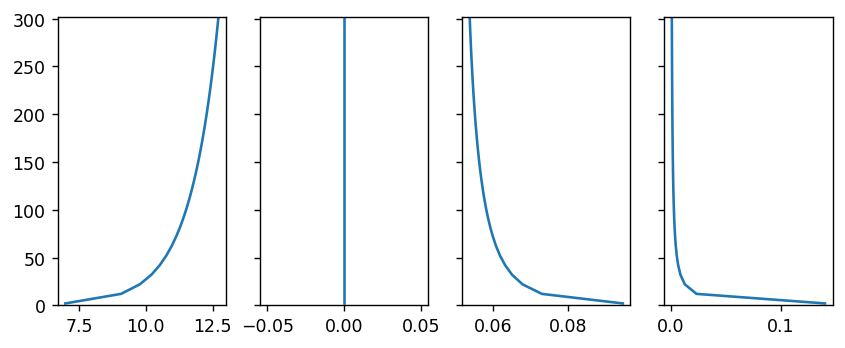

In [8]:
fig, axs = plt.subplots(1,4, sharey=True, dpi=125, figsize=(8,3))
axs[0].plot(Uinit[Ny//2,:], zvec)
axs[1].plot(Vinit[Ny//2,:], zvec)
#axs[2].plot(Kinit[Ny//2,:], zvec)
TITKE = np.sqrt(Kinit[Ny//2,:]*2/3)/Uinit[Ny//2,:]
axs[2].plot(TITKE, zvec)
axs[3].plot(EPSinit[Ny//2,:], zvec)
axs[0].set_ylim([0, zmax])

print(np.interp(turbhh, zvec, TITKE))

In [9]:
xvecplot=[-63, 0, 126, 252, 1008] #600, 1000]
dx  = 63 #150

xvec = np.arange(xvecplot[0], xvecplot[-1]+1.0E-6, dx)
#xvec=[0, 200, 400, 600]

#xvec = xvecplot
start_time = time.time()
phi = SANDwake3D.marchSystem(phiinit, xvec, dy, dz, params, 
                             SANDwake3D.getTypicalWMBC(Uinit[0,-1], params['Tw'], veerBC=Vprof),
                             SANDwake3D.kepsT_eqns, 
                             advanceSys=SANDwake3D.advanceSystemKEPS,
                             verbose=1, maxiter=100, tol=1.0E-4)
end_time = time.time()
execution_time = end_time - start_time
print(f"Execution time: {execution_time:.4f} seconds")

x = 0.0 dx = 63.0
Computing forces for turbine T0
ZLO_WALLBC: {'ustar': 0.31714644485378796, 'Lnext': inf, 'Tstar': 0.0}
C3eps_use: 4.181
avg_dil: 0.0007465847390685982
{'name': 'T0', 'Ct': 0.86, 'power': 1000.123}
x = 63.0 dx = 63.0
ZLO_WALLBC: {'ustar': 0.47742820072584713, 'Lnext': inf, 'Tstar': 0.0}
C3eps_use: 4.181
avg_dil: 0.00022046694285643526
x = 126.0 dx = 63.0
ZLO_WALLBC: {'ustar': 0.43224635781496107, 'Lnext': inf, 'Tstar': 0.0}
C3eps_use: 4.181
avg_dil: 9.298634040195869e-05
x = 189.0 dx = 63.0
ZLO_WALLBC: {'ustar': 0.4388570945615235, 'Lnext': inf, 'Tstar': 0.0}
C3eps_use: 4.181
avg_dil: 5.844937035827845e-05
x = 252.0 dx = 63.0
ZLO_WALLBC: {'ustar': 0.4281475023356238, 'Lnext': inf, 'Tstar': 0.0}
C3eps_use: 4.181
avg_dil: 4.708428433128241e-05
x = 315.0 dx = 63.0
ZLO_WALLBC: {'ustar': 0.4228604359770757, 'Lnext': inf, 'Tstar': 0.0}
C3eps_use: 4.181
avg_dil: 3.778837912772266e-05
x = 378.0 dx = 63.0
ZLO_WALLBC: {'ustar': 0.4162924366686529, 'Lnext': inf, 'Tstar': 0.0}
C3e

(2.0, 302.0)

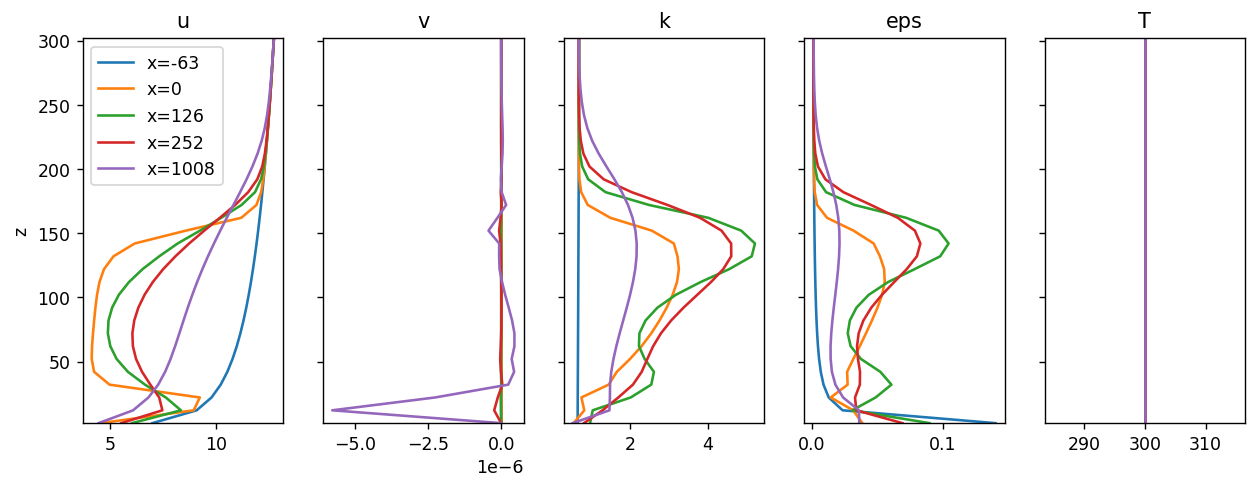

In [10]:
plotvars=['u', 'v', 'k', 'eps', 'T']
find_nearest = lambda a, a0: np.abs(np.array(a) - a0).argmin()
islice = find_nearest(yvec, 0)# Ny//2

#xvecplot=[0, 50]

fig, axs = plt.subplots(1,len(plotvars),figsize=(12,4), dpi=125, sharey=True)
for iv, v in enumerate(plotvars):
    for x in xvecplot:
        ixRANS = find_nearest(xvec, x)
        axs[iv].plot(phi[v][ixRANS,islice,:], zvec, label='x=%.0f'%x)
    axs[iv].set_title(v)
    
axs[0].legend()
axs[0].set_ylabel('z')
axs[0].set_ylim([zmin, zmax])

## Plot XY Wake profiles

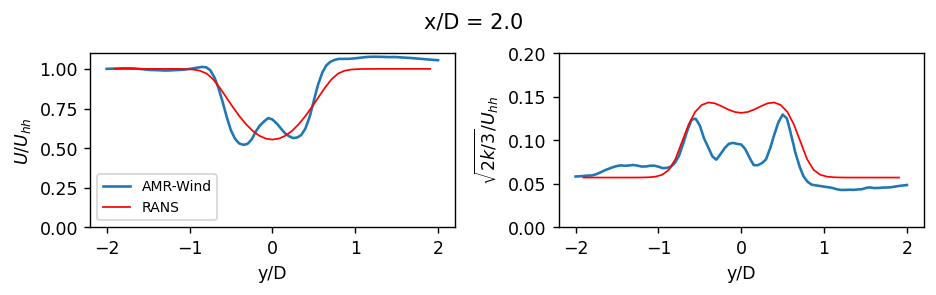

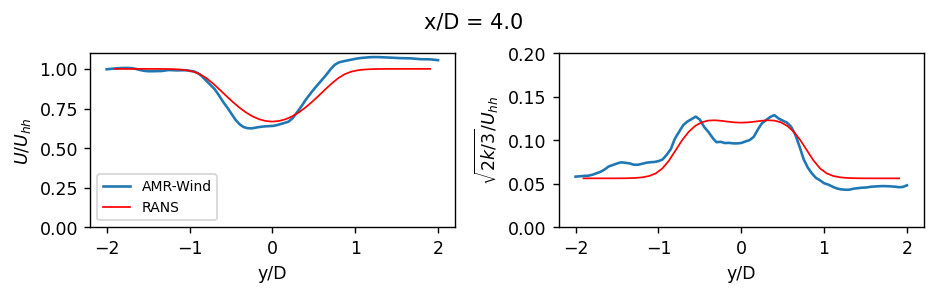

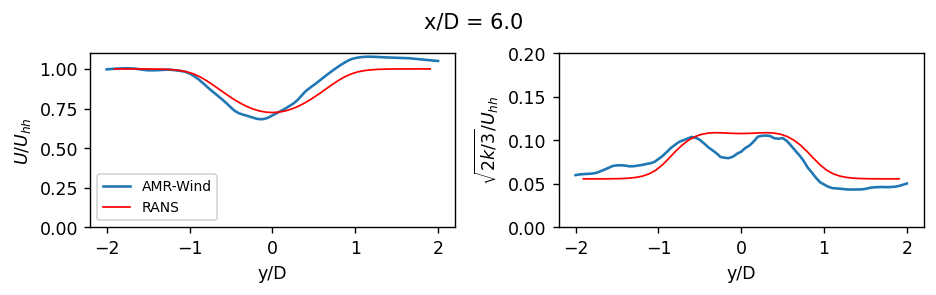

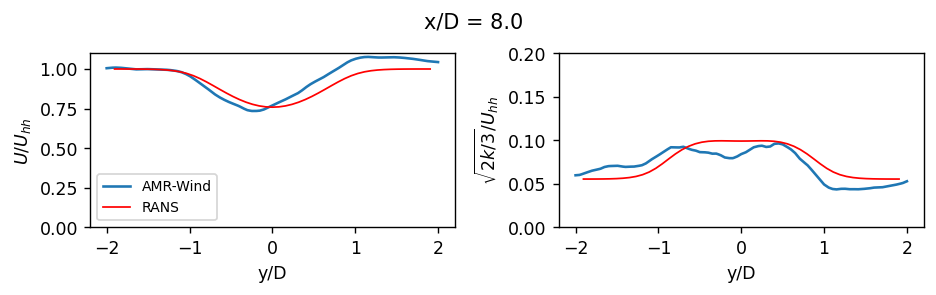

In [11]:
# LES data origin
basedir      = '/projects/wind_uq/lcheung/exawind-benchmarks.redoALM/amr-wind/actuator_line/NREL5MW_ALM_RIGID/results/HHProfiles_300_900/'
baseurl      = 'https://raw.githubusercontent.com/Exawind/exawind-benchmarks/refs/heads/main/amr-wind/actuator_line' +\
               '/NREL5MW_ALM_RIGID/results/HHProfiles_300_900/'
fname        = 'XY_wake_%02i.csv'


Uhh = 11.4
RANS_turbx = 0.0
zvec=params['zm'][0,:]
yvec=params['ym'][:,0]
izRANS = find_nearest(zvec, turbhh)

nondimTKE = lambda k, U: np.sqrt(2.0*k/3.0)/U
xplot=[2,4,6,8]
for x in xplot:
    fig, axs = plt.subplots(1,2,figsize=(7.5,2.5), dpi=125)
    try:
        LESurl   = urllib.request.urlopen(baseurl+fname%x)
        LESdat   = np.loadtxt(LESurl, delimiter=',',skiprows=1)
    except:
        fname        = 'XY_wake_ReStress_%02i.csv'
        LESdat   = np.loadtxt(basedir+fname%x, delimiter=',',skiprows=1)
    WS       = np.sqrt(LESdat[:,5]**2 + LESdat[:,6]**2)
    TKE      = 0.5*(LESdat[:,8] + LESdat[:,11] + LESdat[:,13])
    axs[0].plot((LESdat[:,1]-2*rotorD)/rotorD, WS/Uhh, label='AMR-Wind')
    axs[1].plot((LESdat[:,1]-2*rotorD)/rotorD, nondimTKE(TKE, Uhh), label='AMR-Wind')
    
    ixRANS = find_nearest(xvec, RANS_turbx+x*rotorD)
    axs[0].plot((yvec)/rotorD,  phi['u'][ixRANS,:,izRANS]/Uhh, 'r', label='RANS', lw=1)
    axs[0].set_ylim([0, 1.1])
    
    axs[1].plot((yvec)/rotorD,  nondimTKE(phi['k'][ixRANS,:,izRANS], Uhh), 'r', lw=1)
    axs[1].set_ylim([0, 0.2])

    axs[0].set_xlabel('y/D')
    axs[1].set_xlabel('y/D')
    axs[0].set_ylabel(r'$U/U_{hh}$')
    axs[1].set_ylabel(r'$\sqrt{2 k/3} / U_{hh}$')
    axs[0].legend(fontsize=8, loc='lower left')
    
    fig.suptitle('x/D = %0.1f'%x, y=0.925)
    plt.tight_layout()

In [12]:
T=696.604*1000
#T=564.884*1000
R=rotorD/2
Ct = T/(0.5*np.pi*R**2*Uhh**2)
print(Ct)

0.8597561385252998


In [13]:
def plotrotorlinesax(ax, zhh, rotorD, xstart, xend, **kwargs):
    ax.hlines(zhh,             xstart, xend, linewidth=1.0, **kwargs) # Plot the HH line
    ax.hlines(zhh+rotorD*0.5,  xstart, xend, linewidth=0.5, **kwargs) # Plot the HH line
    ax.hlines(zhh-rotorD*0.5,  xstart, xend, linewidth=0.5, **kwargs) # Plot the HH line 

Text(0, 0.5, 'z [m]')

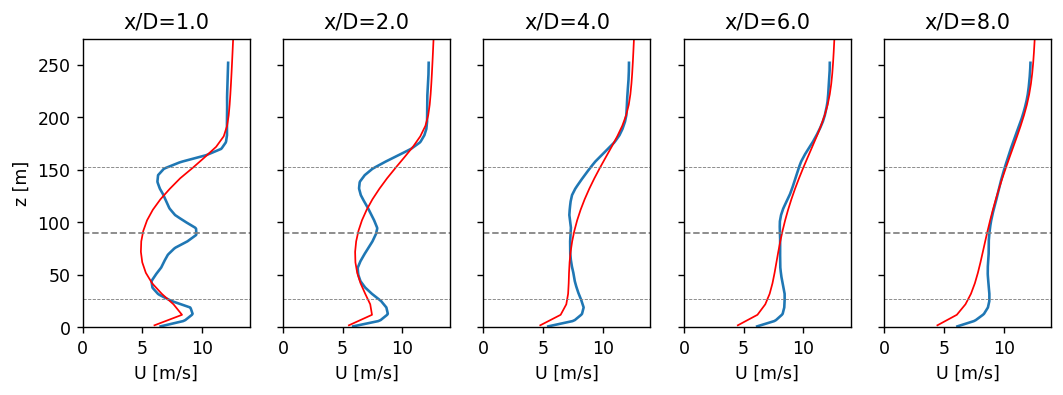

In [14]:
# LES data origin
basedir      = '/projects/wind_uq/lcheung/exawind-benchmarks.redoALM/amr-wind/actuator_line/NREL5MW_ALM_RIGID/results/XZProfiles_300_900/'
baseurl      = 'https://raw.githubusercontent.com/Exawind/exawind-benchmarks/refs/heads/main/amr-wind/actuator_line' +\
               '/NREL5MW_ALM_RIGID/results/XZProfiles_300_900/'
fname        = 'XZ_wake_%02i.csv'

nondimTKE = lambda k, U: np.sqrt(2.0*k/3.0)/U

xplot=[1,2,4,6,8]
fig, axs = plt.subplots(1,len(xplot),figsize=(2*len(xplot),3), dpi=125, sharey=True)

for ix, x in enumerate(xplot):
    try:
        LESurl   = urllib.request.urlopen(baseurl+fname%x)
        LESdat   = np.loadtxt(LESurl, delimiter=',',skiprows=1)
    except:
        LESdat   = np.loadtxt(basedir+fname%x, delimiter=',',skiprows=1)
    WS       = np.sqrt(LESdat[:,5]**2 + LESdat[:,6]**2)
    axs[ix].plot(WS, LESdat[:,1], label='AMR-Wind')
    
    ixRANS = find_nearest(xvec, RANS_turbx+x*rotorD)
    Uh = np.sqrt(phi['u'][ixRANS,islice,:]**2 + phi['v'][ixRANS,islice,:]**2)
    axs[ix].plot(Uh, zvec, 'r-', lw=1, label='RANS')

    axs[ix].set_xlabel('U [m/s]')
    axs[ix].set_title('x/D=%0.1f'%x)
    axs[ix].set_xlim([0, 14])
    axs[ix].set_ylim([0, 275])
    plotrotorlinesax(axs[ix], turbhh, rotorD, 0, 20, linestyles='dashed', color='gray',)

axs[0].set_ylabel('z [m]')


Text(0, 0.5, 'z [m]')

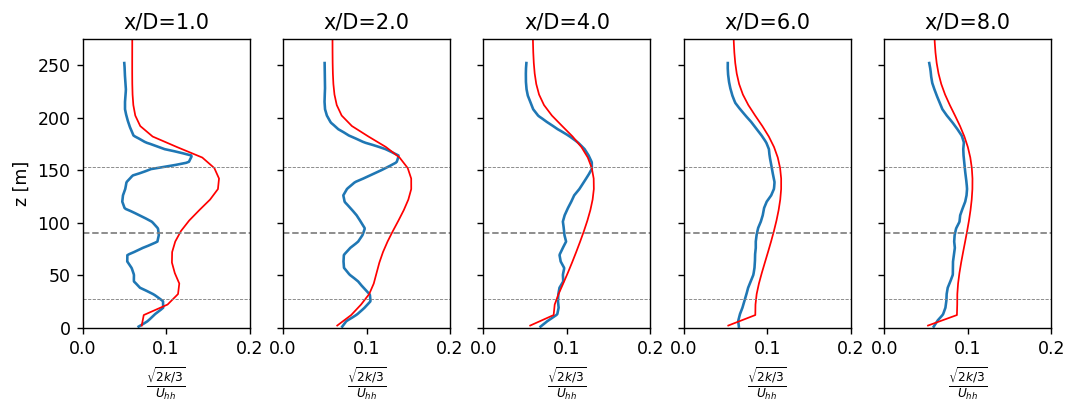

In [15]:
# LES data origin
basedir      = '/projects/wind_uq/lcheung/exawind-benchmarks.redoALM/amr-wind/actuator_line/NREL5MW_ALM_RIGID/results/XZProfiles_300_900/'
baseurl      = 'https://raw.githubusercontent.com/Exawind/exawind-benchmarks/refs/heads/main/amr-wind/actuator_line' +\
               '/NREL5MW_ALM_RIGID/results/XZProfiles_300_900/'
fname        = 'XZ_wake_ReStress_%02i.csv'

nondimTKE = lambda k, U: np.sqrt(2.0*k/3.0)/U

xplot=[1,2,4,6,8]
fig, axs = plt.subplots(1,len(xplot),figsize=(2*len(xplot),3), dpi=125, sharey=True)

for ix, x in enumerate(xplot):
    try:
        LESurl   = urllib.request.urlopen(baseurl+fname%x)
        LESdat   = np.loadtxt(LESurl, delimiter=',',skiprows=1)
    except:
        LESdat   = np.loadtxt(basedir+fname%x, delimiter=',',skiprows=1)
    WS       = np.sqrt(LESdat[:,5]**2 + LESdat[:,6]**2)
    TKE      = 0.5*(LESdat[:,8] + LESdat[:,11] + LESdat[:,13])
    axs[ix].plot(nondimTKE(TKE, Uhh), LESdat[:,1], label='AMR-Wind')

    ixRANS = find_nearest(xvec, RANS_turbx+x*rotorD)
    Uh = np.sqrt(phi['u'][ixRANS,islice,:]**2 + phi['v'][ixRANS,islice,:]**2)
    axs[ix].plot(nondimTKE(phi['k'][ixRANS,islice,:], Uhh), zvec, 'r-', lw=1, label='RANS')

    axs[ix].set_xlabel(r'$\frac{\sqrt{2 k/3}}{U_{hh}}$')
    axs[ix].set_title('x/D=%0.1f'%x)
    axs[ix].set_xlim([0, 0.2])
    axs[ix].set_ylim([0, 275])
    plotrotorlinesax(axs[ix], turbhh, rotorD, 0, 20, linestyles='dashed', color='gray',)
    
axs[0].set_ylabel('z [m]')